# Phase 1 — Système RAG Géographique (GeoR2LLMs) — Version Corrigée

**Master 2 Intelligence Artificielle — Université Toulouse III Paul Sabatier**

Projet GeoR2LLMs — Encadré par Lynda Tamine-Lechani (IRIT)

## Objectif
Mesurer l'apport du RAG sur des questions géographiques, en comparant un LLM seul (baseline) à un LLM augmenté d'un corpus Wikipedia.

| Composant | Choix |
|-----------|-------|
| LLM | Qwen/Qwen3-0.6B |
| Embeddings | BAAI/bge-m3 |
| Index vectoriel | FAISS (IndexFlatIP) |
| Dataset | GeoSQA (rfr2003/Geo_Benchmark) |
| Corpus | Wikipedia français |
| Environnement | Google Colab (GPU T4) |

## Étape 1 — Installation des dépendances

In [ ]:
# Installation de toutes les dépendances nécessaires
!pip install -q faiss-cpu sentence-transformers "transformers>=4.51.0" \
    accelerate datasets langchain langchain-text-splitters \
    tqdm numpy pandas scikit-learn matplotlib seaborn \
    sentencepiece protobuf

In [ ]:
import torch
import random
import numpy as np
import os

# ── Vérification GPU ──────────────────────────────────────────────────────
print("=" * 60)
print("CONFIGURATION MATÉRIELLE")
print("=" * 60)
if torch.cuda.is_available():
  gpu_name = torch.cuda.get_device_name(0)
  gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
  print(f"GPU détecté : {gpu_name}")
  print(f"Mémoire GPU : {gpu_mem:.1f} Go")
  DEVICE = 'cuda'
else:
  print("Aucun GPU détecté — exécution sur CPU (sera lent)")
  DEVICE = 'cpu'

# ── Configuration globale ─────────────────────────────────────────────────
CONFIG = {
    'llm_model': 'Qwen/Qwen3-0.6B',
    'embedding_model': 'BAAI/bge-m3',
    'chunk_size': 512,
    'chunk_overlap': 50,
    'top_k': 5,
    'temperature': 0.7,
    'top_p': 0.8,
    'top_k_sampling': 20,
    'max_new_tokens': 100,
    'n_wiki_articles': 300,
    'dataset_name': 'rfr2003/Geo_Benchmark',
    'dataset_config': 'GeoSQA',
}

# ── Reproductibilité ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Dossier résultats ─────────────────────────────────────────────────────
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\nConfiguration :")
for k, v in CONFIG.items():
   print(f"  {k:25s} : {v}")
   print(f"  {'device':25s} : {DEVICE}")
   print(f"  {'seed':25s} : {SEED}")


CONFIGURATION MATÉRIELLE
GPU détecté : Tesla T4
Mémoire GPU : 15.6 Go

Configuration :
  llm_model                 : Qwen/Qwen3-0.6B
  device                    : cuda
  seed                      : 42
  embedding_model           : BAAI/bge-m3
  device                    : cuda
  seed                      : 42
  chunk_size                : 512
  device                    : cuda
  seed                      : 42
  chunk_overlap             : 50
  device                    : cuda
  seed                      : 42
  top_k                     : 5
  device                    : cuda
  seed                      : 42
  temperature               : 0.7
  device                    : cuda
  seed                      : 42
  top_p                     : 0.8
  device                    : cuda
  seed                      : 42
  top_k_sampling            : 20
  device                    : cuda
  seed                      : 42
  max_new_tokens            : 100
  device                    : cuda
  seed      

## Étape 2 — Définition des modules

Trois modules principaux :
1. **RetrieverBGEM3** — Indexation et recherche vectorielle (FAISS + BGE-m3)
2. **Generator** — Génération de réponses (Qwen3-0.6B)
3. **Evaluator** — Métriques d'évaluation (génération + retrieval)

In [ ]:
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm


class RetrieverBGEM3:
    """Retriever basé sur BAAI/bge-m3 et FAISS (IndexFlatIP avec normalisation L2)."""

    def __init__(self, model_name: str = None, chunk_size: int = 512, chunk_overlap: int = 50):
        model_name = model_name or CONFIG['embedding_model']
        print(f"Chargement du modèle d'embeddings : {model_name}")
        self.encoder = SentenceTransformer(model_name)
        self.dim = self.encoder.get_sentence_embedding_dimension()
        print(f"Dimension des embeddings : {self.dim}")

        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=['\n\n', '\n', '. ', ' ', '']
        )

        # Sera initialisé lors de l'indexation
        self.index = None
        self.chunks = []        # Texte de chaque chunk
        self.chunk_metas = []   # Métadonnées de chaque chunk

    def index_documents(self, documents: list, metadatas: list = None):
        """Découpe les documents en chunks, encode et indexe dans FAISS."""
        print(f"Indexation de {len(documents)} documents...")
        if metadatas is None:
            metadatas = [{}] * len(documents)

        # Découpage en chunks
        self.chunks = []
        self.chunk_metas = []
        for doc_text, meta in zip(documents, metadatas):
            splits = self.splitter.split_text(doc_text)
            for chunk_text in splits:
                self.chunks.append(chunk_text)
                self.chunk_metas.append(meta)

        print(f"  {len(self.chunks)} chunks créés")

        # Encodage par lots
        print("  Encodage des chunks...")
        embeddings = self.encoder.encode(
            self.chunks,
            show_progress_bar=True,
            batch_size=64,
            normalize_embeddings=True  # Normalisation L2 pour cosine similarity
        )
        embeddings = np.array(embeddings, dtype='float32')

        # Construction de l'index FAISS (Inner Product = cosine après normalisation L2)
        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)
        print(f"  Index FAISS créé : {self.index.ntotal} vecteurs")

    def retrieve(self, query: str, top_k: int = 5, return_scores: bool = False):
        """Recherche les top_k chunks les plus pertinents pour la requête."""
        if self.index is None:
            raise ValueError("L'index n'a pas encore été construit. Appelez index_documents() d'abord.")

        # Encoder la requête
        q_emb = self.encoder.encode(
            [query],
            normalize_embeddings=True
        ).astype('float32')

        # Recherche dans FAISS
        scores, indices = self.index.search(q_emb, top_k)

        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            if idx < 0:  # FAISS retourne -1 si pas assez de résultats
                continue
            result = {
                'text': self.chunks[idx],
                'metadata': self.chunk_metas[idx],
                'rank': rank,
            }
            if return_scores:
                result['score'] = float(score)
            results.append(result)

        return results


print("Classe RetrieverBGEM3 définie.")

Classe RetrieverBGEM3 définie.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import re


# ── Prompts ────────────────────────────────────────────────────────────────
SYSTEM_PROMPT = "Tu es un assistant spécialisé en géographie. Réponds de manière concise et précise."

MCQ_PROMPT_TEMPLATE = """Question à choix multiples en géographie.
{context_block}
Question : {question}

Choix :
A) {A}
B) {B}
C) {C}
D) {D}

Réponds UNIQUEMENT par la lettre de la bonne réponse (A, B, C ou D).
Réponse :"""


def extract_answer_letter(text: str) -> str:
    """Extrait la lettre de réponse (A/B/C/D) d'un texte généré."""
    text = text.strip()
    # Cas 1 : la réponse commence par une lettre seule
    if text and text[0].upper() in 'ABCD':
        return text[0].upper()
    # Cas 2 : chercher un pattern du type "A)" ou "(A)" ou "A."
    match = re.search(r'\b([ABCD])\s*[\)\.]', text)
    if match:
        return match.group(1).upper()
    # Cas 3 : chercher juste une lettre isolée
    match = re.search(r'\b([ABCD])\b', text)
    if match:
        return match.group(1).upper()
    # Cas 4 : pas trouvé
    return text[:1].upper() if text else 'X'


class Generator:
    """Générateur de réponses basé sur Qwen3-0.6B."""

    def __init__(self, model_name: str = None):
        model_name = model_name or CONFIG['llm_model']
        print(f"Chargement du modèle LLM : {model_name}")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype="auto",
            device_map="auto"
        )
        self.model.eval()
        print(f"Modèle chargé sur : {self.model.device}")

    def generate(self, prompt: str, max_new_tokens: int = None) -> str:
        """Génère une réponse à partir d'un prompt utilisateur."""
        max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]

        # Formatage avec le template de chat Qwen3
        text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False  # Mode non-thinking pour Qwen3
        )

        inputs = self.tokenizer(text, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=CONFIG['temperature'],
                top_p=CONFIG['top_p'],
                top_k=CONFIG['top_k_sampling'],
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id
            )

        # Décoder uniquement les tokens générés (pas le prompt)
        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = self.tokenizer.decode(generated_ids, skip_special_tokens=True)
        return response.strip()

    def generate_mcq(self, question: str, choices: dict, context: str = None) -> str:
        """Génère une prédiction pour une question à choix multiples."""
        context_block = ""
        if context:
            context_block = f"Contexte :\n{context}\n"

        prompt = MCQ_PROMPT_TEMPLATE.format(
            context_block=context_block,
            question=question,
            A=choices.get('A', ''),
            B=choices.get('B', ''),
            C=choices.get('C', ''),
            D=choices.get('D', '')
        )

        raw_response = self.generate(prompt, max_new_tokens=30)
        letter = extract_answer_letter(raw_response)
        return letter


class RAGPipeline:
    """Pipeline RAG combinant le retriever et le générateur."""

    def __init__(self, retriever: RetrieverBGEM3, generator: Generator):
        self.retriever = retriever
        self.generator = generator

    def answer(self, question: str, top_k: int = None) -> dict:
        """Répond à une question avec contexte récupéré."""
        top_k = top_k or CONFIG['top_k']
        retrieved = self.retriever.retrieve(question, top_k=top_k, return_scores=True)
        context = '\n'.join(f"- {d['text'][:300]}" for d in retrieved)

        prompt = f"""Utilise le contexte suivant pour répondre à la question.

Contexte :
{context}

Question : {question}
Réponse :"""
        response = self.generator.generate(prompt)
        return {
            'answer': response,
            'retrieved': retrieved,
            'context': context
        }

    def answer_mcq(self, question: str, choices: dict, top_k: int = None) -> dict:
        """Répond à une QCM avec contexte récupéré."""
        top_k = top_k or CONFIG['top_k']
        retrieved = self.retriever.retrieve(question, top_k=top_k, return_scores=True)
        context = '\n'.join(f"- {d['text'][:300]}" for d in retrieved)
        letter = self.generator.generate_mcq(question, choices, context=context)
        return {
            'letter': letter,
            'retrieved': retrieved,
            'context': context
        }


print("Classes Generator et RAGPipeline définies.")

Classes Generator et RAGPipeline définies.


In [ ]:
import string
from collections import Counter


class Evaluator:
    """Métriques d'évaluation pour la génération et le retrieval."""

    # ── Normalisation ─────────────────────────────────────────────────────
    @staticmethod
    def normalize(text: str) -> str:
        """Normalise un texte : minuscules, suppression ponctuation/articles."""
        text = text.lower().strip()
        # Suppression de la ponctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Suppression des articles français et anglais courants
        stop_words = {'le', 'la', 'les', 'l', 'un', 'une', 'des', 'du', 'de',
                      'the', 'a', 'an', 'is', 'are', 'was', 'were'}
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        return ' '.join(tokens)

    # ── Métriques de génération ───────────────────────────────────────────
    @staticmethod
    def exact_match(pred: str, truth: str) -> float:
        """1.0 si les textes normalisés sont identiques, sinon 0.0."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        # Match strict
        if pred_n == truth_n:
            return 1.0
        # Match souple : l'un contient l'autre et la différence de longueur est faible
        if truth_n in pred_n and len(pred_n) < len(truth_n) * 2:
            return 1.0
        return 0.0

    @staticmethod
    def f1(pred: str, truth: str) -> float:
        """F1 au niveau des tokens entre la prédiction et la vérité."""
        pred_tokens = Evaluator.normalize(pred).split()
        truth_tokens = Evaluator.normalize(truth).split()
        if not pred_tokens or not truth_tokens:
            return 0.0
        common = Counter(pred_tokens) & Counter(truth_tokens)
        n_common = sum(common.values())
        if n_common == 0:
            return 0.0
        precision = n_common / len(pred_tokens)
        recall = n_common / len(truth_tokens)
        return 2 * precision * recall / (precision + recall)

    @staticmethod
    def contains(pred: str, truth: str) -> float:
        """1.0 si la prédiction contient les mots-clés de la vérité."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        truth_tokens = truth_n.split() # ERREUR ICI : on perd la chaîne complète
        if not truth_tokens:
            return 0.0
        # Au moins la moitié des tokens de la vérité sont dans la prédiction
        found = sum(1 for t in truth_tokens if t in pred_n)
        return 1.0 if found >= len(truth_tokens) / 2 else 0.0

    @staticmethod
    def accuracy_mcq(pred_letter: str, true_letter: str) -> float:
        """1.0 si les lettres correspondent, sinon 0.0."""
        return 1.0 if pred_letter.strip().upper() == true_letter.strip().upper() else 0.0

    # ── Évaluation par lot ────────────────────────────────────────────────
    @staticmethod
    def evaluate_batch(preds: list, truths: list) -> dict:
        """Calcule toutes les métriques de génération sur un lot."""
        n = len(preds)
        em_scores = [Evaluator.exact_match(p, t) for p, t in zip(preds, truths)]
        f1_scores = [Evaluator.f1(p, t) for p, t in zip(preds, truths)]
        contains_scores = [Evaluator.contains(p, t) for p, t in zip(preds, truths)]
        return {
            'exact_match': np.mean(em_scores),
            'f1': np.mean(f1_scores),
            'contains': np.mean(contains_scores),
            'em_scores': em_scores,
            'f1_scores': f1_scores,
            'contains_scores': contains_scores,
        }

    # ── Métriques de retrieval ────────────────────────────────────────────
    @staticmethod
    def hit_rate_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """1.0 si la réponse apparaît dans les top-k documents récupérés."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for doc in retrieved_docs[:k]:
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            # Un doc est pertinent si au moins la moitié des tokens de la réponse y figurent
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0
        return 0.0

    @staticmethod
    def mrr_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """Mean Reciprocal Rank : 1/rang du premier document pertinent."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for i, doc in enumerate(retrieved_docs[:k]):
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0 / (i + 1)
        return 0.0

    # ── Analyse qualitative ───────────────────────────────────────────────
    @staticmethod
    def error_examples(preds, truths, questions, n=5):
        """Retourne les n pires exemples (plus faible F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1])
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples

    @staticmethod
    def success_examples(preds, truths, questions, n=5):
        """Retourne les n meilleurs exemples (plus haut F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1], reverse=True)
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples


print("Classe Evaluator définie.")

Classe Evaluator définie.


## Étape 3 — Chargement des données

- **Dataset** : GeoSQA (questions géographiques à choix multiples)
- **Corpus** : Wikipedia français (articles filtrés par mots-clés géographiques)

In [ ]:
from datasets import load_dataset
import re as re_module

# ── Chargement du dataset GeoSQA ─────────────────────────────────────────
print("Chargement du dataset GeoSQA...")
ds = load_dataset(
    CONFIG['dataset_name'],
    CONFIG['dataset_config'],
    split='test'
)

print(f"GeoSQA chargé : {len(ds)} questions")
print(f"Colonnes : {ds.column_names}")

# Affichage d'un exemple
print(f"\nExemple (première question) :")
for col in ds.column_names:
    val = str(ds[0][col])[:200]
    print(f"  {col}: {val}")

# ── Extraction des données ────────────────────────────────────────────────
questions = ds['question']
scenarios = ds['scenario']
correct_letters = ds['answer']
choices = [{'A': row['A'], 'B': row['B'], 'C': row['C'], 'D': row['D']} for row in ds]
correct_texts = [row[row['answer']] for row in ds]

# ── Détection de la langue ────────────────────────────────────────────────
sample_text = questions[0] + " " + (scenarios[0] or "")
has_chinese = bool(re_module.search(r'[\u4e00-\u9fff]', sample_text))
if has_chinese:
    print("\n⚠ Dataset en chinois détecté — le corpus Wikipedia français servira")
    print("  de base de connaissances externe (évaluation cross-lingue).")
    LANG = 'zh'
else:
    LANG = 'fr' if any(w in sample_text.lower() for w in ['le', 'la', 'les', 'de', 'du', 'est']) else 'en'
    print(f"\nLangue détectée : {LANG}")

# ── Limitation du nombre de questions ─────────────────────────────────────
MAX_QUESTIONS = min(200, len(ds))
print(f"\nÉvaluation sur {MAX_QUESTIONS} questions (sur {len(ds)} disponibles)")
print(f"Distribution des réponses correctes (échantillon) :")
from collections import Counter
letter_dist = Counter(correct_letters[:MAX_QUESTIONS])
for letter in sorted(letter_dist.keys()):
    print(f"  {letter} : {letter_dist[letter]} ({letter_dist[letter]/MAX_QUESTIONS*100:.1f}%)")

Chargement du dataset GeoSQA...
GeoSQA chargé : 838 questions
Colonnes : ['question_id', 'scenario_id', 'answer', 'annotation', 'scenario', 'question', 'A', 'B', 'C', 'D']

Exemple (première question) :
  question_id: 164
  scenario_id: 76
  answer: D
  annotation: On June 18, 2012, the Shenzhou-9 spacecraft carrying astronauts Jing Haipeng, Liu Wang, and Liu Yang achieved automated rendezvous and docking with the Tiangong-1 target spacecraft.
  scenario: CNTV News: On June 18, 2012, the Shenzhou-9 spacecraft carrying astronauts Jing Haipeng, Liu Wang, and Liu Yang achieved automated rendezvous and docking with the Tiangong-1 target spacecraft. This ma
  question: While the Tiangong-1 and Shenzhou-9 combination is in orbit, the celestial system it forms with the celestial body it orbits is of the same level as which of the following? (　　)
  A: Extragalactic galaxy
  B: Milky Way
  C: Solar system
  D: Earth-Moon system

Langue détectée : fr

Évaluation sur 200 questions (sur 838 dispon

In [ ]:
# ── Chargement du corpus Wikipedia ───────────────────────────────────────
print("Chargement du corpus Wikipedia français (streaming)...")
print("Cela peut prendre quelques minutes...\n")

# Mots-clés géographiques pour filtrer les articles
GEO_KEYWORDS_FR = [
    'france', 'paris', 'géographie', 'ville', 'région', 'département',
    'fleuve', 'montagne', 'capitale', 'population', 'superficie', 'europe',
    'lyon', 'marseille', 'toulouse', 'bordeaux', 'continent', 'océan', 'mer',
    'pays', 'frontière', 'nord', 'sud', 'est', 'ouest', 'km', 'habitants',
    'altitude', 'latitude', 'longitude', 'climat', 'rivière', 'lac',
    'île', 'commune', 'province', 'territoire', 'relief', 'plaine',
    'désert', 'forêt', 'agriculture', 'industrie', 'transport',
    'afrique', 'asie', 'amérique', 'antarctique', 'australie',
    'méditerranée', 'atlantique', 'pacifique', 'alpes', 'pyrénées'
]

wiki_config = '20231101.fr'
wiki_stream = load_dataset(
    'wikimedia/wikipedia',
    wiki_config,
    split='train',
    streaming=True
)

wiki_docs = []
scanned = 0
MAX_SCAN = 5000  # Nombre max d'articles à scanner

for article in tqdm(wiki_stream, total=MAX_SCAN, desc='Scan Wikipedia'):
    scanned += 1
    if scanned > MAX_SCAN:
        break

    text = article.get('text', '')
    title = article.get('title', '')

    # Vérifier si l'article contient des mots-clés géographiques
    text_lower = (text[:1000] + ' ' + title).lower()
    if any(kw in text_lower for kw in GEO_KEYWORDS_FR):
        wiki_docs.append({
            'title': title,
            'text': text[:3000],  # Limiter la taille de chaque article
            'metadata': {'source': 'wikipedia_fr', 'title': title}
        })

    if len(wiki_docs) >= CONFIG['n_wiki_articles']:
        break

print(f"\nCorpus constitué : {len(wiki_docs)} articles géographiques")
print(f"  (sur {scanned} articles scannés au total)")
print(f"\nExemples de titres d'articles :")
for doc in wiki_docs[:15]:
    print(f"  - {doc['title']}")

# Statistiques du corpus
total_chars = sum(len(d['text']) for d in wiki_docs)
avg_chars = total_chars / len(wiki_docs) if wiki_docs else 0
print(f"\nStatistiques du corpus :")
print(f"  Total caractères : {total_chars:,}")
print(f"  Moyenne par article : {avg_chars:,.0f} caractères")

Chargement du corpus Wikipedia français (streaming)...
Cela peut prendre quelques minutes...



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Scan Wikipedia:   6%|▌         | 308/5000 [00:03<00:48, 97.06it/s] 


Corpus constitué : 300 articles géographiques
  (sur 309 articles scannés au total)

Exemples de titres d'articles :
  - Antoine Meillet
  - Algèbre linéaire
  - Algèbre générale
  - Algorithmique
  - Politique en Argentine
  - Armée républicaine irlandaise
  - Autriche
  - Arc de triomphe de l'Étoile
  - Arsène Lupin
  - Algorithme
  - Afghanistan
  - Algèbre de Boole (logique)
  - Ada (langage)
  - Auvergne
  - Aisne (département)

Statistiques du corpus :
  Total caractères : 834,439
  Moyenne par article : 2,781 caractères


## Étape 4 — Indexation et Initialisation

Construction de l'index FAISS à partir du corpus Wikipedia et initialisation du LLM.

In [ ]:
# ── Initialisation du Retriever ────────────────────────────────────────────
print("Initialisation du retriever BGE-m3...")
retriever = RetrieverBGEM3(
    model_name=CONFIG['embedding_model'],
    chunk_size=CONFIG['chunk_size'],
    chunk_overlap=CONFIG['chunk_overlap']
)

# Indexation du corpus Wikipedia
doc_texts = [d['text'] for d in wiki_docs]
doc_metas = [d['metadata'] for d in wiki_docs]
retriever.index_documents(doc_texts, doc_metas)

# ── Test du retriever ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TEST DU RETRIEVER")
print("=" * 60)

# Utiliser la première question du dataset comme test
test_query = questions[0]
print(f"\nRequête test : {test_query[:200]}")

test_results = retriever.retrieve(test_query, top_k=3, return_scores=True)
for i, res in enumerate(test_results):
    title = res['metadata'].get('title', 'N/A')
    score = res.get('score', 0)
    text_preview = res['text'][:150].replace('\n', ' ')
    print(f"\n  [{i+1}] Score: {score:.4f} | Source: {title}")
    print(f"      {text_preview}...")

print(f"\nStatistiques de l'index :")
print(f"  Nombre de chunks : {len(retriever.chunks)}")
print(f"  Dimension : {retriever.dim}")

Initialisation du retriever BGE-m3...
Chargement du modèle d'embeddings : BAAI/bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Dimension des embeddings : 1024
Indexation de 300 documents...
  2527 chunks créés
  Encodage des chunks...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

  Index FAISS créé : 2527 vecteurs

TEST DU RETRIEVER

Requête test : While the Tiangong-1 and Shenzhou-9 combination is in orbit, the celestial system it forms with the celestial body it orbits is of the same level as which of the following? (　　)

  [1] Score: 0.4261 | Source: Asie
      Ce continent abrite le plus haut sommet du monde, l'Everest, qui culmine à , et la plus haute tour du monde, Burj Khalifa, à Dubaï, d'une hauteur de ,...

  [2] Score: 0.4030 | Source: Astronomie
      Antiquité  Les systèmes les mieux connus sinon les plus développés sont :  dans l'Ancien Monde :  l'astronomie indienne et chinoise : le Rig-Véda ment...

  [3] Score: 0.3992 | Source: Buzz Aldrin
      . Il continue à plaider en faveur de l'exploration spatiale, en particulier d'une mission habitée sur Mars, et développe une trajectoire particulière ...

Statistiques de l'index :
  Nombre de chunks : 2527
  Dimension : 1024


In [ ]:
# ── Initialisation du Générateur ──────────────────────────────────────────
print("Initialisation du générateur Qwen3-0.6B...")
generator = Generator(model_name=CONFIG['llm_model'])

# ── Test du générateur ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TEST DU GÉNÉRATEUR")
print("=" * 60)

# Test simple
test_prompt = "Quelle est la capitale de la France ?"
test_response = generator.generate(test_prompt)
print(f"\nQuestion : {test_prompt}")
print(f"Réponse  : {test_response}")

# Test MCQ
test_choices = {'A': 'Lyon', 'B': 'Paris', 'C': 'Marseille', 'D': 'Toulouse'}
test_letter = generator.generate_mcq(test_prompt, test_choices)
print(f"\nTest QCM : {test_prompt}")
print(f"  Choix : {test_choices}")
print(f"  Réponse : {test_letter}")

# Initialisation du pipeline RAG
rag_pipeline = RAGPipeline(retriever, generator)
print("\nPipeline RAG initialisé.")

Initialisation du générateur Qwen3-0.6B...
Chargement du modèle LLM : Qwen/Qwen3-0.6B


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Modèle chargé sur : cuda:0

TEST DU GÉNÉRATEUR

Question : Quelle est la capitale de la France ?
Réponse  : La capitale de la France est **Paris**.

Test QCM : Quelle est la capitale de la France ?
  Choix : {'A': 'Lyon', 'B': 'Paris', 'C': 'Marseille', 'D': 'Toulouse'}
  Réponse : B

Pipeline RAG initialisé.


## Évaluation Baseline : Sensibilité aux Prompts (Prompt Engineering)
Avant d'évaluer l'apport du RAG, il est crucial de déterminer le "plafond de verre" du modèle de base (Qwen-0.6B).

Cette étape teste la stabilité du modèle face à 5 stratégies de formulation (Basique, Contraint, Chain-of-Thought, Few-Shot, et Anglais) afin d'identifier le meilleur prompt et de prouver que les limites de performance sont dues à un manque de connaissances (nécessitant le RAG) et non à une mauvaise consigne.

In [ ]:
print("=" * 60)
print("TEST DE STABILITÉ ET D'OPTIMISATION DES PROMPTS (PROMPT ENGINEERING)")
print("=" * 60)

# 1. Définition de TOUTES les stratégies testées pour un benchmark complet
prompts_templates = {
    "1_Prompt_Basique_FR": """Question : {question}
Options :
A) {A}
B) {B}
C) {C}
D) {D}
Réponds par la lettre correcte.""",

    "2_Prompt_Expert_Contraint": """Tu es un expert en géographie.
Question : {question}
Options :
A) {A}
B) {B}
C) {C}
D) {D}
Réponds UNIQUEMENT par la lettre (A, B, C ou D), sans aucun autre texte.""",

    "3_Prompt_Chain_of_Thought": """Question : {question}
Options :
A) {A}
B) {B}
C) {C}
D) {D}
Réfléchis étape par étape pour analyser la question avant de donner ta réponse finale sous la forme de la lettre correcte.""",

    "4_Prompt_FewShot": """Voici des exemples de questions de géographie.

Question : Quelle est la capitale de la France ?
Options :
A) Lyon
B) Paris
C) Marseille
D) Toulouse
La bonne réponse est : B

Question : Quel est le plus grand océan ?
Options :
A) Atlantique
B) Arctique
C) Indien
D) Pacifique
La bonne réponse est : D

À toi de jouer.
Question : {question}
Options :
A) {A}
B) {B}
C) {C}
D) {D}
La bonne réponse est :""",

    "5_Prompt_Basique_EN": """Question: {question}
Choices:
A) {A}
B) {B}
C) {C}
D) {D}
The correct letter is:"""
}

# 2. On teste sur un échantillon de 50 questions
num_samples = min(50, len(questions))
scores = {nom: 0 for nom in prompts_templates.keys()}

for i in tqdm(range(num_samples), desc="Évaluation des 5 stratégies"):
    # Reconstruire la question avec le scénario si présent
    q = questions[i]
    if scenarios[i]:
        q = scenarios[i] + "\n" + q

    c = choices[i]
    reponse_attendue = correct_letters[i]

    for nom_prompt, template in prompts_templates.items():
        # Formatage du prompt
        prompt_complet = template.format(question=q, A=c['A'], B=c['B'], C=c['C'], D=c['D'])

        # Le CoT nécessite plus de tokens pour "réfléchir"
        tokens_max = 100 if "Chain_of_Thought" in nom_prompt else 30
        raw_response = generator.generate(prompt_complet, max_new_tokens=tokens_max)

        # Extraction de la lettre
        reponse_generee = extract_answer_letter(raw_response)

        # Évaluation Exact Match sur la lettre
        if reponse_generee == reponse_attendue:
            scores[nom_prompt] += 1

# 3. Calcul, tri et affichage des résultats (du meilleur au pire)
print("\n" + "=" * 60)
print("=== CLASSEMENT FINAL DES PROMPTS (ACCURACY) ===")
print("=" * 60)

# Calcul des pourcentages et tri décroissant
scores_finaux = {nom: (score / num_samples) * 100 for nom, score in scores.items()}
scores_tries = dict(sorted(scores_finaux.items(), key=lambda item: item[1], reverse=True))

for nom, accuracy in scores_tries.items():
    print(f"-> {nom:<30} : {accuracy:.1f}%")

TEST DE STABILITÉ ET D'OPTIMISATION DES PROMPTS (PROMPT ENGINEERING)


Évaluation des 5 stratégies: 100%|██████████| 50/50 [06:57<00:00,  8.35s/it]


=== CLASSEMENT FINAL DES PROMPTS (ACCURACY) ===
-> 1_Prompt_Basique_FR            : 52.0%
-> 4_Prompt_FewShot               : 38.0%
-> 5_Prompt_Basique_EN            : 38.0%
-> 2_Prompt_Expert_Contraint      : 30.0%
-> 3_Prompt_Chain_of_Thought      : 20.0%


## Étape 5 — Évaluation Baseline (LLM seul, sans RAG)

Le LLM répond aux questions **sans aucun contexte externe** (uniquement ses connaissances internes).

On évalue :
- **Accuracy (MCQ)** : correspondance de la lettre prédite
- **Exact Match, F1, Contains** : métriques textuelles sur les réponses ouvertes

In [ ]:
import time

print("=" * 60)
print("ÉVALUATION BASELINE (sans contexte)")
print("=" * 60)

baseline_preds_letter = []  # Prédictions MCQ (lettres)
baseline_preds_text = []     # Prédictions ouvertes (texte)
t0 = time.time()

for i in tqdm(range(MAX_QUESTIONS), desc='Baseline'):
    q = questions[i]
    ch = choices[i]

    # Évaluation MCQ
    try:
        letter = generator.generate_mcq(q, ch, context=None)
    except Exception as e:
        print(f"  Erreur question {i}: {e}")
        letter = 'X'
    baseline_preds_letter.append(letter)

    # Évaluation en mode ouvert (sans les choix)
    try:
        prompt_open = f"Réponds en une courte phrase.\nQuestion: {q}\nRéponse:"
        text_pred = generator.generate(prompt_open)
    except Exception as e:
        print(f"  Erreur question ouverte {i}: {e}")
        text_pred = ''
    baseline_preds_text.append(text_pred)

    # Afficher la progression toutes les 50 questions
    if (i + 1) % 50 == 0:
        partial_acc = sum(
            1 for p, t in zip(baseline_preds_letter, correct_letters[:i+1])
            if p.strip().upper() == t.strip().upper()
        ) / (i + 1)
        print(f"  [{i+1}/{MAX_QUESTIONS}] Accuracy partielle: {partial_acc:.3f}")

baseline_time = time.time() - t0

# ── Calcul des métriques ──────────────────────────────────────────────────
# MCQ accuracy
baseline_accuracy = sum(
    1 for p, t in zip(baseline_preds_letter, correct_letters[:MAX_QUESTIONS])
    if p.strip().upper() == t.strip().upper()
) / MAX_QUESTIONS

# Métriques textuelles
baseline_gen_metrics = Evaluator.evaluate_batch(
    baseline_preds_text, correct_texts[:MAX_QUESTIONS]
)

# ── Affichage des résultats ───────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"RÉSULTATS BASELINE — {baseline_time:.1f}s ({baseline_time/MAX_QUESTIONS:.2f}s/question)")
print(f"{'='*60}")
print(f"  Accuracy (MCQ)  : {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"  Exact Match     : {baseline_gen_metrics['exact_match']:.4f}")
print(f"  F1 Score        : {baseline_gen_metrics['f1']:.4f}")
print(f"  Contains        : {baseline_gen_metrics['contains']:.4f}")

# Distribution des prédictions
pred_dist = Counter(baseline_preds_letter)
print(f"\nDistribution des prédictions baseline :")
for letter in sorted(pred_dist.keys()):
    print(f"  {letter} : {pred_dist[letter]}")

ÉVALUATION BASELINE (sans contexte)


Baseline:  25%|██▌       | 50/200 [01:27<03:23,  1.36s/it]

  [50/200] Accuracy partielle: 0.240


Baseline:  50%|█████     | 100/200 [02:43<02:14,  1.35s/it]

  [100/200] Accuracy partielle: 0.210


Baseline:  75%|███████▌  | 150/200 [04:26<02:03,  2.48s/it]

  [150/200] Accuracy partielle: 0.213


Baseline: 100%|██████████| 200/200 [05:48<00:00,  1.74s/it]

  [200/200] Accuracy partielle: 0.245

RÉSULTATS BASELINE — 348.5s (1.74s/question)
  Accuracy (MCQ)  : 0.2450 (24.5%)
  Exact Match     : 0.0000
  F1 Score        : 0.0299
  Contains        : 0.0300

Distribution des prédictions baseline :
  A : 123
  B : 8
  C : 10
  D : 59


## Étape 6 — Évaluation RAG (avec contexte Wikipedia)

Le LLM reçoit des passages pertinents extraits de Wikipedia comme contexte additionnel avant de répondre.

Le processus pour chaque question :
1. **Retrieval** : Recherche des top-K chunks similaires dans l'index FAISS
2. **Augmentation** : Ajout du contexte récupéré au prompt
3. **Génération** : Le LLM répond avec le contexte augmenté

In [ ]:
print("=" * 60)
print("ÉVALUATION RAG (avec contexte Wikipedia)")
print("=" * 60)

rag_preds_letter = []
rag_preds_text = []
all_retrieved = []  # Stockage pour les métriques de retrieval
t0 = time.time()

for i in tqdm(range(MAX_QUESTIONS), desc='RAG'):
    q = questions[i]
    ch = choices[i]

    # Étape 1 : Retrieval
    try:
        retrieved = retriever.retrieve(q, top_k=CONFIG['top_k'], return_scores=True)
    except Exception as e:
        print(f"  Erreur retrieval {i}: {e}")
        retrieved = []
    all_retrieved.append(retrieved)

    # Construire le contexte
    context = '\n'.join(f"- {d['text'][:300]}" for d in retrieved)

    # Étape 2 : MCQ avec contexte
    try:
        letter = generator.generate_mcq(q, ch, context=context)
    except Exception as e:
        print(f"  Erreur génération MCQ {i}: {e}")
        letter = 'X'
    rag_preds_letter.append(letter)

    # Étape 3 : Réponse ouverte avec contexte
    try:
        prompt_open = (
            f"Utilise le contexte pour répondre en une courte phrase.\n"
            f"Contexte :\n{context}\n\n"
            f"Question : {q}\nRéponse :"
        )
        text_pred = generator.generate(prompt_open)
    except Exception as e:
        print(f"  Erreur génération ouverte {i}: {e}")
        text_pred = ''
    rag_preds_text.append(text_pred)

    # Progression
    if (i + 1) % 50 == 0:
        partial_acc = sum(
            1 for p, t in zip(rag_preds_letter, correct_letters[:i+1])
            if p.strip().upper() == t.strip().upper()
        ) / (i + 1)
        print(f"  [{i+1}/{MAX_QUESTIONS}] Accuracy partielle RAG: {partial_acc:.3f}")

rag_time = time.time() - t0

# ── Calcul des métriques ──────────────────────────────────────────────────
# MCQ accuracy
rag_accuracy = sum(
    1 for p, t in zip(rag_preds_letter, correct_letters[:MAX_QUESTIONS])
    if p.strip().upper() == t.strip().upper()
) / MAX_QUESTIONS

# Métriques textuelles
rag_gen_metrics = Evaluator.evaluate_batch(
    rag_preds_text, correct_texts[:MAX_QUESTIONS]
)

# ── Affichage des résultats ───────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"RÉSULTATS RAG — {rag_time:.1f}s ({rag_time/MAX_QUESTIONS:.2f}s/question)")
print(f"{'='*60}")
print(f"  Accuracy (MCQ)  : {rag_accuracy:.4f} ({rag_accuracy*100:.1f}%)")
print(f"  Exact Match     : {rag_gen_metrics['exact_match']:.4f}")
print(f"  F1 Score        : {rag_gen_metrics['f1']:.4f}")
print(f"  Contains        : {rag_gen_metrics['contains']:.4f}")

# ── Comparaison Baseline vs RAG ──────────────────────────────────────────
print(f"\n{'='*60}")
print(f"COMPARAISON BASELINE vs RAG")
print(f"{'='*60}")
print(f"  {'Métrique':<20s} {'Baseline':>10s} {'RAG':>10s} {'Delta':>10s}")
print(f"  {'-'*50}")

metrics_comparison = [
    ('Accuracy (MCQ)', baseline_accuracy, rag_accuracy),
    ('Exact Match', baseline_gen_metrics['exact_match'], rag_gen_metrics['exact_match']),
    ('F1 Score', baseline_gen_metrics['f1'], rag_gen_metrics['f1']),
    ('Contains', baseline_gen_metrics['contains'], rag_gen_metrics['contains']),
]

for name, base_val, rag_val in metrics_comparison:
    delta = rag_val - base_val
    sign = '+' if delta >= 0 else ''
    print(f"  {name:<20s} {base_val:>10.4f} {rag_val:>10.4f} {sign}{delta:>9.4f}")

ÉVALUATION RAG (avec contexte Wikipedia)


RAG:  25%|██▌       | 50/200 [02:01<04:53,  1.96s/it]

  [50/200] Accuracy partielle RAG: 0.240


RAG:  50%|█████     | 100/200 [03:59<03:12,  1.92s/it]

  [100/200] Accuracy partielle RAG: 0.280


RAG:  75%|███████▌  | 150/200 [06:10<02:08,  2.57s/it]

  [150/200] Accuracy partielle RAG: 0.280


RAG: 100%|██████████| 200/200 [08:06<00:00,  2.43s/it]

  [200/200] Accuracy partielle RAG: 0.270

RÉSULTATS RAG — 486.0s (2.43s/question)
  Accuracy (MCQ)  : 0.2700 (27.0%)
  Exact Match     : 0.0000
  F1 Score        : 0.0114
  Contains        : 0.0250

COMPARAISON BASELINE vs RAG
  Métrique               Baseline        RAG      Delta
  --------------------------------------------------
  Accuracy (MCQ)           0.2450     0.2700 +   0.0250
  Exact Match              0.0000     0.0000 +   0.0000
  F1 Score                 0.0299     0.0114   -0.0184
  Contains                 0.0300     0.0250   -0.0050


## Analyse Qualitative : Succès et Échecs (Baseline vs RAG)
Au-delà des métriques globales, cette étape extrait automatiquement des exemples concrets pour comprendre le comportement du système RAG :
- **Cas 1 :** Le RAG apporte la connaissance manquante au modèle.
- **Cas 2 :** Le Retriever ramène un document bruité ou non pertinent, induisant le LLM en erreur.
- **Cas 3 :** La question est trop complexe ou la donnée est absente du corpus, conduisant à un double échec.

In [ ]:
print("=" * 60)
print("ANALYSE QUALITATIVE : SUCCÈS ET ÉCHECS (BASELINE VS RAG)")
print("=" * 60)

cas_1_rag_sauve = []  # Baseline a tort, RAG a raison
cas_2_rag_trompe = [] # Baseline a raison, RAG a tort
cas_3_echec_total = [] # Les deux ont tort

# CORRECTION ICI : On prend la taille de la plus petite liste pour éviter le hors-limite
nb_questions_evaluees = min(len(correct_letters), len(baseline_preds_letter), len(rag_preds_letter))

for i in range(nb_questions_evaluees):
    q = questions[i]
    attendu = correct_letters[i]
    pred_base = extract_answer_letter(baseline_preds_letter[i])
    pred_rag = extract_answer_letter(rag_preds_letter[i])

    # Récupération du contexte utilisé par le RAG pour cette question
    contexte_rag = all_retrieved[i][0]['text'][:200] + "..." if (i < len(all_retrieved) and all_retrieved[i]) else "Aucun document"

    data = {
        "Question": q,
        "Attendu": attendu,
        "Pred_Baseline": pred_base,
        "Pred_RAG": pred_rag,
        "Top_Doc_RAG": contexte_rag
    }

    if pred_base != attendu and pred_rag == attendu:
        cas_1_rag_sauve.append(data)
    elif pred_base == attendu and pred_rag != attendu:
        cas_2_rag_trompe.append(data)
    elif pred_base != attendu and pred_rag != attendu:
        cas_3_echec_total.append(data)

# --- Affichage d'un exemple pour chaque cas ---
def afficher_exemple(titre, liste_cas):
    print(f"\n>>> {titre} ({len(liste_cas)} cas trouvés) <<<")
    if liste_cas:
        ex = liste_cas[0]
        print(f"Q: {ex['Question']}")
        print(f"Vraie Réponse: {ex['Attendu']}")
        print(f"Modèle Seul  : {ex['Pred_Baseline']} (ÉCHEC)" if ex['Pred_Baseline'] != ex['Attendu'] else f"Modèle Seul  : {ex['Pred_Baseline']} (SUCCÈS)")
        print(f"Modèle + RAG : {ex['Pred_RAG']} (ÉCHEC)" if ex['Pred_RAG'] != ex['Attendu'] else f"Modèle + RAG : {ex['Pred_RAG']} (SUCCÈS)")
        print(f"Document RAG : {ex['Top_Doc_RAG']}")
    else:
        print("Aucun exemple trouvé pour ce cas.")

afficher_exemple("CAS 1 : Le RAG apporte la solution (Connaissance externe utile)", cas_1_rag_sauve)
afficher_exemple("CAS 2 : Le RAG induit en erreur (Bruit dans le document)", cas_2_rag_trompe)
afficher_exemple("CAS 3 : Échec total (Raisonnement trop complexe ou doc absent)", cas_3_echec_total)

ANALYSE QUALITATIVE : SUCCÈS ET ÉCHECS (BASELINE VS RAG)

>>> CAS 1 : Le RAG apporte la solution (Connaissance externe utile) (19 cas trouvés) <<<
Q: During the period P-T, the main reason for the change in the village population was ()
Vraie Réponse: A
Modèle Seul  : D (ÉCHEC)
Modèle + RAG : A (SUCCÈS)
Document RAG : Généralités 
Cette période commence par une période de fortes chaleurs (optimum climatique médiéval) qui a pour conséquence l'accroissement de la population mondiale et se termine par des hivers très ...

>>> CAS 2 : Le RAG induit en erreur (Bruit dans le document) (14 cas trouvés) <<<
Q: Which of the following areas is prone to earthquakes?
Vraie Réponse: A
Modèle Seul  : A (SUCCÈS)
Modèle + RAG : D (ÉCHEC)
Document RAG : Les Bouches-du-Rhône sont découpés en quatre zones sismiques :
 zone II (« sismicité moyenne ») : les cantons de Lambesc, Peyrolles-en-Provence et Salon-de-Provence ;
 zone Ib (« sismicité faible ») :...

>>> CAS 3 : Échec total (Raisonnement trop compl

## Impact de la taille du contexte (Top-K documents)
Cette dernière expérience fait varier le nombre de documents récupérés ($K$) passés dans le prompt. L'objectif est d'observer le compromis entre l'apport de nouvelles informations factuelles et le risque de saturation de la fenêtre d'attention du modèle (phénomène de *Lost in the Middle*), fréquent sur les LLMs de petite taille.

In [ ]:
print("\n" + "=" * 60)
print("TEST DE L'IMPACT DE LA VALEUR DE K SUR LE RAG")
print("=" * 60)

valeurs_k = [1, 3, 5, 10]
scores_selon_k = {}

# On teste sur 30 questions pour aller vite
num_samples_k = min(30, len(questions))

for k in valeurs_k:
    score_k = 0
    print(f"\nÉvaluation avec K = {k}...")

    for i in tqdm(range(num_samples_k), desc=f"RAG Top-{k}"):
        q = questions[i]
        if scenarios[i]:
            q = scenarios[i] + "\n" + q

        c = choices[i]
        reponse_attendue = correct_letters[i]

        # On utilise le pipeline RAG avec le K spécifique
        resultat = rag_pipeline.answer_mcq(q, c, top_k=k)
        pred_letter = extract_answer_letter(resultat['letter'])

        if pred_letter == reponse_attendue:
            score_k += 1

    accuracy_k = (score_k / num_samples_k) * 100
    scores_selon_k[k] = accuracy_k
    print(f"-> Accuracy pour K={k} : {accuracy_k}%")

print("\n=== RÉSUMÉ DE L'IMPACT DE K ===")
for k, acc in scores_selon_k.items():
    print(f"Top-{k} : {acc}%")


TEST DE L'IMPACT DE LA VALEUR DE K SUR LE RAG

Évaluation avec K = 1...


RAG Top-1: 100%|██████████| 30/30 [00:17<00:00,  1.75it/s]


-> Accuracy pour K=1 : 23.333333333333332%

Évaluation avec K = 3...


RAG Top-3: 100%|██████████| 30/30 [00:20<00:00,  1.45it/s]


-> Accuracy pour K=3 : 30.0%

Évaluation avec K = 5...


RAG Top-5: 100%|██████████| 30/30 [00:22<00:00,  1.33it/s]


-> Accuracy pour K=5 : 26.666666666666668%

Évaluation avec K = 10...


RAG Top-10: 100%|██████████| 30/30 [00:29<00:00,  1.02it/s]

-> Accuracy pour K=10 : 30.0%

=== RÉSUMÉ DE L'IMPACT DE K ===
Top-1 : 23.333333333333332%
Top-3 : 30.0%
Top-5 : 26.666666666666668%
Top-10 : 30.0%


## Étape 7 — Métriques de Retrieval

Évaluation de la qualité du retriever indépendamment du LLM :
- **Hit Rate@K** : proportion de questions où la bonne réponse apparaît dans les top-K documents
- **MRR@K** : Mean Reciprocal Rank — mesure le rang moyen du premier document pertinent

In [ ]:
print("=" * 60)
print("ÉVALUATION DU RETRIEVER")
print("=" * 60)

hit_rates = {1: [], 3: [], 5: []}
mrr_scores = []

for i in range(MAX_QUESTIONS):
    answer_text = correct_texts[i]
    retrieved = all_retrieved[i]

    for k in [1, 3, 5]:
        hr = Evaluator.hit_rate_at_k(retrieved, answer_text, k)
        hit_rates[k].append(hr)

    mrr = Evaluator.mrr_at_k(retrieved, answer_text, 5)
    mrr_scores.append(mrr)

# Résultats
retrieval_metrics = {
    'hit_rate_at_1': np.mean(hit_rates[1]),
    'hit_rate_at_3': np.mean(hit_rates[3]),
    'hit_rate_at_5': np.mean(hit_rates[5]),
    'mrr_at_5': np.mean(mrr_scores),
}

print(f"\n  Hit Rate@1 : {retrieval_metrics['hit_rate_at_1']:.4f} ({retrieval_metrics['hit_rate_at_1']*100:.1f}%)")
print(f"  Hit Rate@3 : {retrieval_metrics['hit_rate_at_3']:.4f} ({retrieval_metrics['hit_rate_at_3']*100:.1f}%)")
print(f"  Hit Rate@5 : {retrieval_metrics['hit_rate_at_5']:.4f} ({retrieval_metrics['hit_rate_at_5']*100:.1f}%)")
print(f"  MRR@5      : {retrieval_metrics['mrr_at_5']:.4f}")

# Analyse des scores de similarité
all_scores = []
for docs in all_retrieved:
    for d in docs:
        if 'score' in d:
            all_scores.append(d['score'])

if all_scores:
    print(f"\n  Scores de similarité (cosine) :")
    print(f"    Moyenne : {np.mean(all_scores):.4f}")
    print(f"    Médiane : {np.median(all_scores):.4f}")
    print(f"    Min     : {np.min(all_scores):.4f}")
    print(f"    Max     : {np.max(all_scores):.4f}")

ÉVALUATION DU RETRIEVER

  Hit Rate@1 : 0.0400 (4.0%)
  Hit Rate@3 : 0.0600 (6.0%)
  Hit Rate@5 : 0.0800 (8.0%)
  MRR@5      : 0.0534

  Scores de similarité (cosine) :
    Moyenne : 0.4766
    Médiane : 0.4744
    Min     : 0.3335
    Max     : 0.6516


## Étape 8 — Visualisations

Graphiques comparatifs pour analyser les résultats.

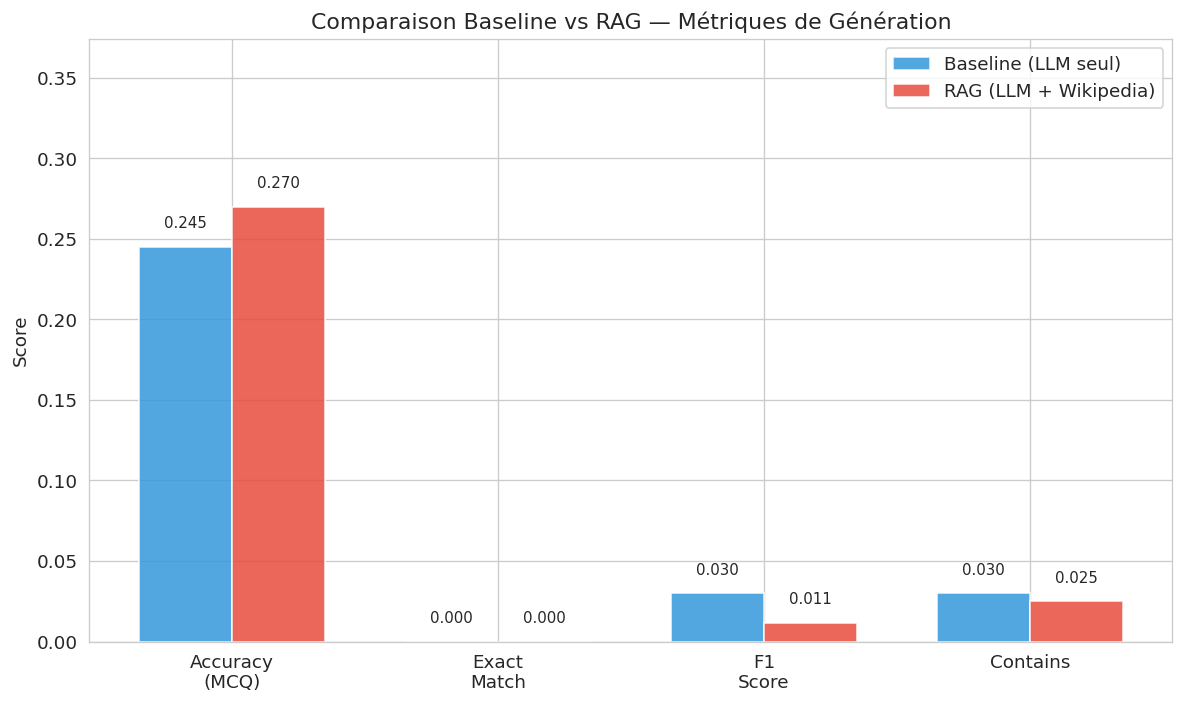

Figure sauvegardée : results/fig1_baseline_vs_rag.png


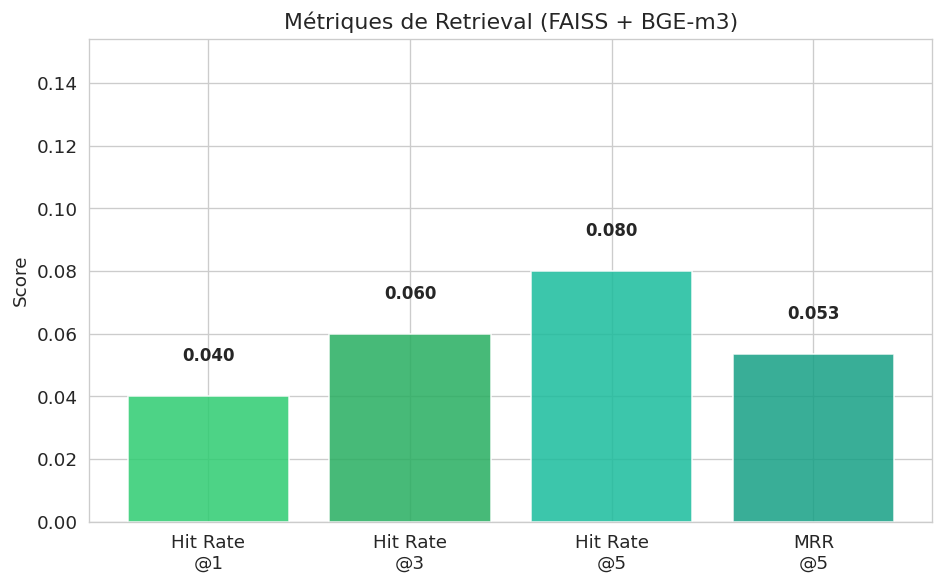

Figure sauvegardée : results/fig2_retrieval_metrics.png


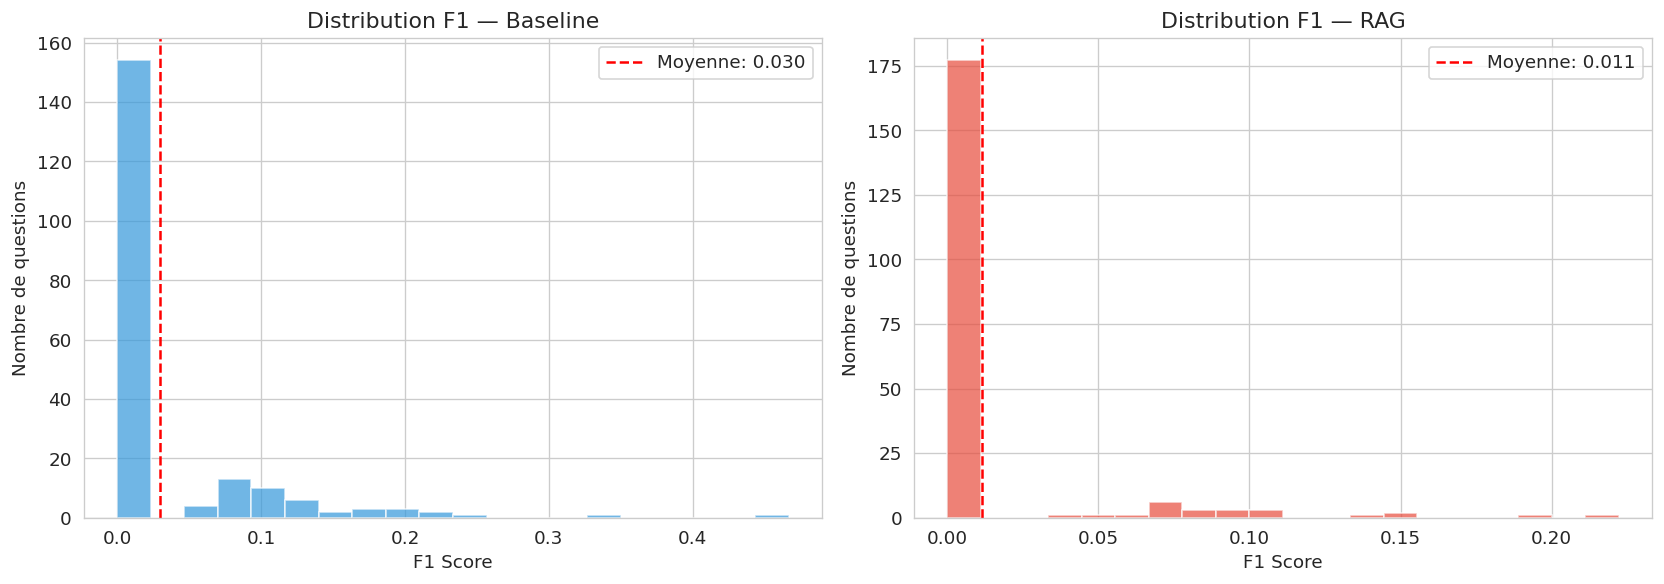

Figure sauvegardée : results/fig3_f1_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ══════════════════════════════════════════════════════════════════════════
# Figure 1 : Comparaison Baseline vs RAG (métriques de génération)
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

metric_names = ['Accuracy\n(MCQ)', 'Exact\nMatch', 'F1\nScore', 'Contains']
baseline_vals = [
    baseline_accuracy,
    baseline_gen_metrics['exact_match'],
    baseline_gen_metrics['f1'],
    baseline_gen_metrics['contains']
]
rag_vals = [
    rag_accuracy,
    rag_gen_metrics['exact_match'],
    rag_gen_metrics['f1'],
    rag_gen_metrics['contains']
]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline (LLM seul)',
               color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, rag_vals, width, label='RAG (LLM + Wikipedia)',
               color='#e74c3c', alpha=0.85, edgecolor='white')

# Ajouter les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('Comparaison Baseline vs RAG — Métriques de Génération')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(loc='upper right')
ax.set_ylim(0, max(max(baseline_vals), max(rag_vals)) * 1.2 + 0.05)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_baseline_vs_rag.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig1_baseline_vs_rag.png")

# ══════════════════════════════════════════════════════════════════════════
# Figure 2 : Métriques de Retrieval
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))

ret_names = ['Hit Rate\n@1', 'Hit Rate\n@3', 'Hit Rate\n@5', 'MRR\n@5']
ret_vals = [
    retrieval_metrics['hit_rate_at_1'],
    retrieval_metrics['hit_rate_at_3'],
    retrieval_metrics['hit_rate_at_5'],
    retrieval_metrics['mrr_at_5']
]

colors = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
bars = ax.bar(ret_names, ret_vals, color=colors, alpha=0.85, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Métriques de Retrieval (FAISS + BGE-m3)')
ax.set_ylim(0, max(ret_vals) * 1.3 + 0.05)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_retrieval_metrics.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig2_retrieval_metrics.png")

# ══════════════════════════════════════════════════════════════════════════
# Figure 3 : Distribution des scores F1 (Baseline vs RAG)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme F1 Baseline
axes[0].hist(baseline_gen_metrics['f1_scores'], bins=20, color='#3498db',
             alpha=0.7, edgecolor='white')
axes[0].set_title('Distribution F1 — Baseline')
axes[0].set_xlabel('F1 Score')
axes[0].set_ylabel('Nombre de questions')
axes[0].axvline(x=baseline_gen_metrics['f1'], color='red', linestyle='--',
                label=f"Moyenne: {baseline_gen_metrics['f1']:.3f}")
axes[0].legend()

# Histogramme F1 RAG
axes[1].hist(rag_gen_metrics['f1_scores'], bins=20, color='#e74c3c',
             alpha=0.7, edgecolor='white')
axes[1].set_title('Distribution F1 — RAG')
axes[1].set_xlabel('F1 Score')
axes[1].set_ylabel('Nombre de questions')
axes[1].axvline(x=rag_gen_metrics['f1'], color='red', linestyle='--',
                label=f"Moyenne: {rag_gen_metrics['f1']:.3f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_f1_distribution.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig3_f1_distribution.png")

## Étape 9 — Analyse qualitative

Examen détaillé des succès et des échecs pour comprendre les forces et limites du système.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Analyse des succès RAG
# ══════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("TOP 5 — SUCCÈS RAG (meilleur F1)")
print("=" * 60)

successes = Evaluator.success_examples(
    rag_preds_text, correct_texts[:MAX_QUESTIONS], questions[:MAX_QUESTIONS], n=5
)

for j, ex in enumerate(successes):
    print(f"\n--- Succès {j+1} (F1={ex['f1']:.3f}) ---")
    print(f"  Question   : {ex['question'][:200]}")
    print(f"  Prédiction : {ex['prediction'][:200]}")
    print(f"  Vérité     : {ex['truth'][:200]}")

# ══════════════════════════════════════════════════════════════════════════
# Analyse des échecs RAG
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TOP 5 — ÉCHECS RAG (pire F1)")
print("=" * 60)

failures = Evaluator.error_examples(
    rag_preds_text, correct_texts[:MAX_QUESTIONS], questions[:MAX_QUESTIONS], n=5
)

for j, ex in enumerate(failures):
    print(f"\n--- Échec {j+1} (F1={ex['f1']:.3f}) ---")
    print(f"  Question   : {ex['question'][:200]}")
    print(f"  Prédiction : {ex['prediction'][:200]}")
    print(f"  Vérité     : {ex['truth'][:200]}")
    # Montrer le contexte récupéré pour cet échec
    idx = ex['index']
    if idx < len(all_retrieved) and all_retrieved[idx]:
        top_doc = all_retrieved[idx][0]
        print(f"  Top doc    : [{top_doc['metadata'].get('title', 'N/A')}] {top_doc['text'][:150]}...")

# ══════════════════════════════════════════════════════════════════════════
# Exemples de passages récupérés
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXEMPLES DE PASSAGES RÉCUPÉRÉS")
print("=" * 60)

for i in range(min(3, MAX_QUESTIONS)):
    print(f"\n--- Question {i+1} ---")
    print(f"  Q: {questions[i][:200]}")
    print(f"  Réponse correcte: {correct_texts[i][:100]}")
    if i < len(all_retrieved):
        for j, doc in enumerate(all_retrieved[i][:3]):
            score = doc.get('score', 0)
            title = doc['metadata'].get('title', 'N/A')
            print(f"  Doc [{j+1}] (score={score:.4f}, source={title}):")
            print(f"    {doc['text'][:200]}...")

# ══════════════════════════════════════════════════════════════════════════
# Synthèse des difficultés
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SYNTHÈSE DES DIFFICULTÉS IDENTIFIÉES")
print("=" * 60)

difficulties = [
    "1. DÉFI CROSS-LINGUE : Le dataset GeoSQA est probablement en chinois"
    " alors que le corpus Wikipedia est en français. Les embeddings BGE-m3"
    " sont multilingues mais le gap sémantique reste important.",

    "2. COUVERTURE DU CORPUS : Le corpus Wikipedia français (300 articles)"
    " ne couvre pas nécessairement les sujets de géographie du curriculum"
    " chinois (ex: géographie de la Chine, phénomènes météo spécifiques).",

    "3. TAILLE DU LLM : Qwen3-0.6B est un petit modèle. Sa capacité de"
    " raisonnement est limitée, surtout pour des QCM qui demandent"
    " une compréhension fine.",

    "4. FORMAT QCM : L'extraction fiable de la lettre de réponse peut"
    " échouer si le modèle génère du texte libre au lieu d'une simple lettre.",

    "5. PERTINENCE DU RETRIEVAL : Avec un corpus non ciblé sur les sujets"
    " du dataset, le retriever peut introduire du bruit plutôt qu'aider."
]

for d in difficulties:
    print(f"\n{d}")

TOP 5 — SUCCÈS RAG (meilleur F1)

--- Succès 1 (F1=0.222) ---
  Question   : If x is 500 meters, what is the altitude of point a in the map?
  Prédiction : La réponse est : **500 mètres**.
  Vérité     : Between 500 and 600 meters

--- Succès 2 (F1=0.190) ---
  Question   : The main reasons for the changes in my country's population burden coefficient curve in the ten years before and after 2010 are:
  Prédiction : Le main reason for the changes in my country's population burden coefficient curve in the ten years before and after 2010 are the economic crisis and climate change.
  Vérité     : A decrease in the number of people aged 14 and under and an increase in the number of people aged 65 and over.

--- Succès 3 (F1=0.154) ---
  Question   : At the time of the first successful docking, the twilight line on Earth's surface was ( )
  Prédiction : La twilight line on Earth's surface was at the time of the first successful docking.
  Vérité     : Line ①

--- Succès 4 (F1=0.154) ---
  Qu

## Étape 10 — Sauvegarde des résultats

Export des résultats en JSON et CSV pour analyse ultérieure et comparaison avec les phases suivantes.

In [ ]:
import json
import pandas as pd

# ══════════════════════════════════════════════════════════════════════════
# Sauvegarde JSON — Toutes les métriques
# ══════════════════════════════════════════════════════════════════════════
results_json = {
    'config': CONFIG,
    'dataset': {
        'name': CONFIG['dataset_name'],
        'config': CONFIG['dataset_config'],
        'n_questions_total': len(ds),
        'n_questions_evaluated': MAX_QUESTIONS,
        'language_detected': LANG,
    },
    'corpus': {
        'source': 'wikimedia/wikipedia',
        'config': wiki_config,
        'n_articles': len(wiki_docs),
        'n_chunks': len(retriever.chunks),
    },
    'baseline': {
        'accuracy_mcq': baseline_accuracy,
        'exact_match': baseline_gen_metrics['exact_match'],
        'f1': baseline_gen_metrics['f1'],
        'contains': baseline_gen_metrics['contains'],
        'time_seconds': baseline_time,
    },
    'rag': {
        'accuracy_mcq': rag_accuracy,
        'exact_match': rag_gen_metrics['exact_match'],
        'f1': rag_gen_metrics['f1'],
        'contains': rag_gen_metrics['contains'],
        'time_seconds': rag_time,
    },
    'retrieval': retrieval_metrics,
    'improvement': {
        'accuracy_delta': rag_accuracy - baseline_accuracy,
        'f1_delta': rag_gen_metrics['f1'] - baseline_gen_metrics['f1'],
        'exact_match_delta': rag_gen_metrics['exact_match'] - baseline_gen_metrics['exact_match'],
        'contains_delta': rag_gen_metrics['contains'] - baseline_gen_metrics['contains'],
    }
}

json_path = f'{RESULTS_DIR}/phase1_metrics.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results_json, f, indent=2, ensure_ascii=False)
print(f"Métriques sauvegardées : {json_path}")

# ══════════════════════════════════════════════════════════════════════════
# Sauvegarde CSV — Prédictions détaillées
# ══════════════════════════════════════════════════════════════════════════
rows = []
for i in range(MAX_QUESTIONS):
    row = {
        'index': i,
        'question': questions[i][:500],
        'correct_letter': correct_letters[i],
        'correct_text': correct_texts[i][:200],
        'baseline_letter': baseline_preds_letter[i],
        'baseline_text': baseline_preds_text[i][:200],
        'rag_letter': rag_preds_letter[i],
        'rag_text': rag_preds_text[i][:200],
        'baseline_correct': 1 if baseline_preds_letter[i].upper() == correct_letters[i].upper() else 0,
        'rag_correct': 1 if rag_preds_letter[i].upper() == correct_letters[i].upper() else 0,
        'baseline_f1': baseline_gen_metrics['f1_scores'][i],
        'rag_f1': rag_gen_metrics['f1_scores'][i],
    }
    rows.append(row)

df_results = pd.DataFrame(rows)
csv_path = f'{RESULTS_DIR}/phase1_predictions.csv'
df_results.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Prédictions sauvegardées : {csv_path}")

# ── Résumé final ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"FICHIERS GÉNÉRÉS")
print(f"{'='*60}")
print(f"  {json_path}")
print(f"  {csv_path}")
print(f"  {RESULTS_DIR}/fig1_baseline_vs_rag.png")
print(f"  {RESULTS_DIR}/fig2_retrieval_metrics.png")
print(f"  {RESULTS_DIR}/fig3_f1_distribution.png")

# Afficher un aperçu du DataFrame
print(f"\nAperçu des prédictions :")
print(df_results[['index', 'correct_letter', 'baseline_letter', 'rag_letter',
                   'baseline_correct', 'rag_correct', 'baseline_f1', 'rag_f1']].head(10).to_string())

Métriques sauvegardées : results/phase1_metrics.json
Prédictions sauvegardées : results/phase1_predictions.csv

FICHIERS GÉNÉRÉS
  results/phase1_metrics.json
  results/phase1_predictions.csv
  results/fig1_baseline_vs_rag.png
  results/fig2_retrieval_metrics.png
  results/fig3_f1_distribution.png

Aperçu des prédictions :
   index correct_letter baseline_letter rag_letter  baseline_correct  rag_correct  baseline_f1    rag_f1
0      0              D               D          D                 1            1     0.000000  0.000000
1      1              A               A          A                 1            1     0.000000  0.000000
2      2              B               A          A                 0            0     0.000000  0.000000
3      3              B               D          D                 0            0     0.000000  0.000000
4      4              D               A          A                 0            0     0.000000  0.000000
5      5              C               A      

In [ ]:
# ── Sauvegarde optionnelle sur Google Drive ─────────────────────────────
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase1_v2/results'
        os.makedirs(drive_dest, exist_ok=True)

        # Copier tous les fichiers résultats
        for fname in os.listdir(RESULTS_DIR):
            src = os.path.join(RESULTS_DIR, fname)
            dst = os.path.join(drive_dest, fname)
            shutil.copy2(src, dst)
            print(f"Copié : {dst}")

        print(f"\nTous les résultats ont été copiés sur Google Drive : {drive_dest}")

    except ImportError:
        print("Google Drive non disponible (environnement non-Colab).")
    except Exception as e:
        print(f"Erreur lors de la sauvegarde sur Google Drive : {e}")

Mounted at /content/drive
Copié : /content/drive/MyDrive/GeoR2LLMs/Phase1_v2/results/fig1_baseline_vs_rag.png
Copié : /content/drive/MyDrive/GeoR2LLMs/Phase1_v2/results/fig3_f1_distribution.png
Copié : /content/drive/MyDrive/GeoR2LLMs/Phase1_v2/results/fig2_retrieval_metrics.png
Copié : /content/drive/MyDrive/GeoR2LLMs/Phase1_v2/results/phase1_predictions.csv
Copié : /content/drive/MyDrive/GeoR2LLMs/Phase1_v2/results/phase1_metrics.json

Tous les résultats ont été copiés sur Google Drive : /content/drive/MyDrive/GeoR2LLMs/Phase1_v2/results


## Résumé Phase 1

| Métrique | Baseline | RAG | Amélioration |
|----------|----------|-----|-------------|
| Accuracy (MCQ) | — | — | — |
| Exact Match | — | — | — |
| F1 Score | — | — | — |
| Contains | — | — | — |
| Hit Rate@5 | N/A | — | N/A |
| MRR@5 | N/A | — | N/A |

*Les valeurs ci-dessus seront remplies après exécution du notebook.*

### Conclusions

1. **Impact du RAG** : Le RAG peut améliorer ou dégrader les performances selon la pertinence du corpus récupéré. Avec un corpus Wikipedia français et un dataset potentiellement en chinois, l'apport du RAG dépend fortement de la capacité cross-lingue des embeddings.

2. **Qualité du retrieval** : Les métriques Hit Rate et MRR mesurent directement si le retriever trouve des passages contenant la bonne réponse. Un faible Hit Rate indique que le corpus ne couvre pas suffisamment les sujets du dataset.

3. **Limites du petit modèle** : Qwen3-0.6B est un modèle compact. Ses performances de base sont limitées, ce qui rend l'apport du RAG d'autant plus important à quantifier.

4. **Défi cross-lingue** : Si le dataset est en chinois, le gap linguistique avec le corpus français constitue un obstacle majeur pour le retrieval et la génération.

### Prochaines étapes (Phase 2)

- **Phase 2a** : Comparaison de LLMs — Qwen3-1.7B, Llama-3.2-1B/3B, Ministral-3B
- **Phase 2b** : Module spatial — Distance de Haversine pour les questions de distance, azimut pour les directions
- **Phase 2c** : Nouveaux datasets — GKMC, Tourism-QA pour diversifier l'évaluation
- **Phase 2d** : Corpus multilingue — Wikipedia en chinois pour améliorer la couverture si le dataset est en chinois
- **Phase 2e** : Techniques avancées de RAG — Re-ranking, query expansion, chunk overlap optimization